# Real Estate Analysis
## Exploratory Data Analysis
* **Goal:** TBA

In [2]:
# Import libraries for Exploratory Analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Safe Dataloading
real_estate_data = ('../data/world_real_estate_data(147k).csv')

try:
    df = pd.read_csv(real_estate_data)
    print(f'File Loaded successfully')
except FileNotFoundError:
    print(f'File Not Found - check {real_estate_data}')
except Exception as e:
    print(f'Error occured - check {e}')

File Loaded successfully


In [4]:
# Inspection of Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147536 entries, 0 to 147535
Data columns (total 14 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   title                       147536 non-null  object 
 1   country                     147406 non-null  object 
 2   location                    147405 non-null  object 
 3   building_construction_year  64719 non-null   float64
 4   building_total_floors       68224 non-null   float64
 5   apartment_floor             54592 non-null   float64
 6   apartment_rooms             74178 non-null   float64
 7   apartment_bedrooms          36982 non-null   float64
 8   apartment_bathrooms         55973 non-null   float64
 9   apartment_total_area        141796 non-null  object 
 10  apartment_living_area       27712 non-null   object 
 11  price_in_USD                144961 non-null  float64
 12  image                       147536 non-null  object 
 13  url           

In [5]:
# Check columns
print(f'Rows: {df.shape[0]} -- Columns: {df.shape[1]}')

Rows: 147536 -- Columns: 14


In [6]:
# Check metrics of Dataset

df.describe()

,building_construction_year,building_total_floors,apartment_floor,apartment_rooms,apartment_bedrooms,apartment_bathrooms,price_in_USD
count,64719.000000,68224.000000,54592.000000,74178.000000,36982.000000,55973.000000,1.449610e+05
mean,1996.921754,8.575692,5.791709,2.572097,2.289222,1.364229,4.121722e+05
std,157.527635,8.356781,5.541368,1.319545,18.276913,0.745019,8.420984e+05
min,1.000000,-1.000000,-2.000000,-1.000000,-1.000000,1.000000,0.000000e+00
25%,2004.000000,2.000000,2.000000,2.000000,1.000000,1.000000,1.054200e+05
50%,2021.000000,5.000000,4.000000,2.000000,2.000000,1.000000,1.902120e+05
75%,2024.000000,14.000000,8.000000,3.000000,3.000000,2.000000,3.989300e+05
max,2316.000000,124.000000,202.000000,124.000000,2009.000000,43.000000,3.060283e+07


**Note:** Further insepction of 'building_total_floors', 'apartment_floor' and 'appartment_bedrooms', because of negative min values.

In [7]:
# Inspection of first 5 rows

df.head()

,title,country,location,building_construction_year,building_total_floors,apartment_floor,apartment_rooms,apartment_bedrooms,apartment_bathrooms,apartment_total_area,apartment_living_area,price_in_USD,image,url
0,2 room apartment 120 m² in Mediterranean Regio...,Turkey,"Mediterranean Region, Turkey",NaN,5.0,1.0,3.0,2.0,2.0,120 m²,110 m²,315209.0,https://realting.com/uploads/bigSlider/ab3/888...,https://realting.com/property-for-sale/turkey/...
1,"4 room villa 500 m² in Kalkan, Turkey",Turkey,"Kalkan, Mediterranean Region, Kas, Turkey",2021.0,2.0,NaN,NaN,NaN,NaN,500 m²,480 m²,1108667.0,https://realting.com/uploads/bigSlider/87b/679...,https://realting.com/property-for-sale/turkey/...
2,"1 room apartment 65 m² in Antalya, Turkey",Turkey,"Mediterranean Region, Antalya, Turkey",NaN,5.0,2.0,2.0,1.0,1.0,65 m²,60 m²,173211.0,https://realting.com/uploads/bigSlider/030/a11...,https://realting.com/property-for-sale/turkey/...
3,"1 room apartment in Pattaya, Thailand",Thailand,"Chon Buri Province, Pattaya, Thailand",2020.0,15.0,5.0,2.0,1.0,1.0,NaN,40 m²,99900.0,https://realting.com/uploads/bigSlider/e9a/e06...,https://realting.com/property-for-sale/thailan...
4,"2 room apartment in Pattaya, Thailand",Thailand,"Chon Buri Province, Pattaya, Thailand",2026.0,8.0,3.0,3.0,2.0,1.0,NaN,36 m²,67000.0,https://realting.com/uploads/bigSlider/453/aa2...,https://realting.com/property-for-sale/thailan...


In [8]:
# Check missing values

df.isna().sum()

title                              0
country                          130
location                         131
building_construction_year     82817
building_total_floors          79312
apartment_floor                92944
apartment_rooms                73358
apartment_bedrooms            110554
apartment_bathrooms            91563
apartment_total_area            5740
apartment_living_area         119824
price_in_USD                    2575
image                              0
url                                0
dtype: int64

**Note:** Missing values need to be handled in FE.

In [17]:
# Checking the negativ values for 'building_total_floors'
print(df['building_total_floors'].min())
print(df['building_total_floors'].value_counts().sort_index().head())

-1.0
building_total_floors
-1.0        1
 1.0    10198
 2.0     8209
 3.0     6158
 4.0     4493
Name: count, dtype: int64


In [16]:
# Checking negativ values for 'apartment_floor'
print(df['apartment_floor'].min())
print(df['apartment_floor'].value_counts().sort_index().head())

-2.0
apartment_floor
-2.0       1
-1.0     414
 1.0    9257
 2.0    7994
 3.0    6847
Name: count, dtype: int64


In [18]:
# Checking negativ values for 'apartment_bedrooms'
print(df['apartment_bedrooms'].min())
print(df['apartment_bedrooms'].value_counts().sort_index().head())

-1.0
apartment_bedrooms
-1.0       37
 1.0    11269
 2.0    14433
 3.0     8550
 4.0     1968
Name: count, dtype: int64


### Initial Assessment of Negative Values

Negative values were found in `building_total_floors`, `apartment_floor` and `apartment_bedrooms`.

- `building_total_floors = -1` is likely an invalid value, as a building cannot have a negative number of floors.
- `apartment_floor = -1` could potentially represent a basement or another below-ground floor and should therefore be investigated further before being removed.
- `apartment_bedrooms = -1` occurs only 37 times and may represent missing or unspecified information.

These values will be considered individually during the data-cleaning process rather than being removed automatically.

In [19]:
# Check for duplicates
df.duplicated().sum()

np.int64(0)

**Note:** No Duplicates in the dataset

In [25]:
# Check prices by country
display(
    df.groupby('country')['price_in_USD']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .sort_values('mean', ascending=False)
)

,count,mean,median,min,max
country,,,,,
Italy,3002,1.631403e+06,792638.0,23754.0,30602832.0
UAE,2674,1.308989e+06,514822.5,60500.0,29131024.0
United States,414,1.232923e+06,672637.0,108364.0,16843557.0
Portugal,2103,9.649344e+05,675032.0,136620.0,7929687.0
Spain,14937,7.388327e+05,384429.0,32696.0,21738563.0
Croatia,2025,7.147181e+05,413033.0,70647.0,5807513.0
Greece,12341,6.550324e+05,404395.0,30434.0,10981710.0
Australia,1,5.590000e+05,559000.0,559000.0,559000.0
Latvia,2294,5.443125e+05,375574.5,34782.0,6557750.0


### Prices by Country

The analysis shows noticeable differences in both the number of properties and their prices across countries.

- **Italy** has a relatively low number of properties compared to countries such as Spain, Turkey and Hungary, but shows the highest average (`mean`) and median property prices in the dataset.
- **Spain, Turkey and Hungary** have significantly higher numbers of properties, while their average and median prices are considerably lower than those of Italy.
- The large difference between the mean and median in several countries suggests that high-priced properties may be influencing the average price.
- **Hungary** has a minimum price of `$0`, which appears unusual and should be investigated further during the data-cleaning process.
- Countries with very few properties, such as Australia with only one observation, should not be used for meaningful comparisons.

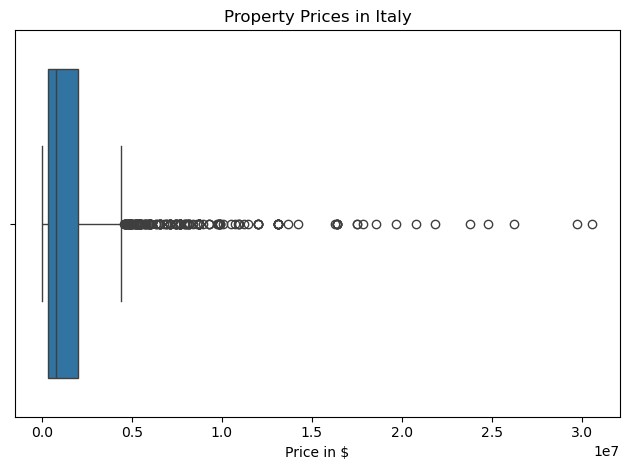

In [26]:
# Check Price for Italy via Boxplot

italy = df[df['country'] == 'Italy']

sns.boxplot(data=italy, x='price_in_USD')

plt.title('Property Prices in Italy')
plt.xlabel('Price in $')
plt.tight_layout()
plt.show()

### Price Distribution in Italy

The boxplot shows a strongly right-skewed distribution of property prices in Italy. Most properties are concentrated in the lower price range, while numerous high-value outliers extend to more than $30 million.

These extreme values likely pull the mean price of approximately $1.63 million upward. With a median of approximately $793,000, the median appears to be a more representative measure of the typical property price.

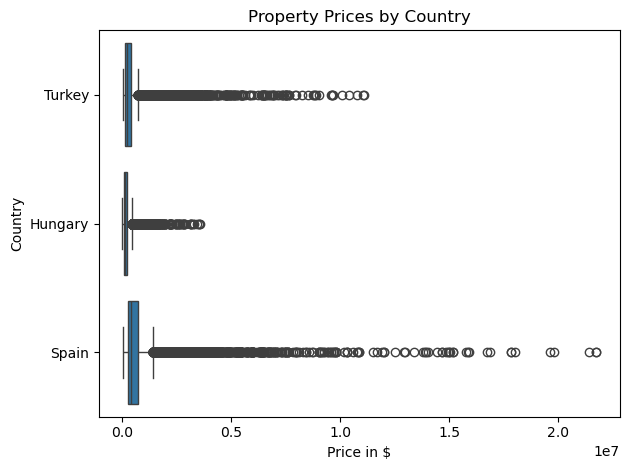

In [ ]:
# Check for Price Distribution for Spain, Turkey and Hungary

countries = ['Spain', 'Turkey', 'Hungary', 'Italy']

sns.boxplot(
    data=df[df['country'].isin(countries)],
    x='price_in_USD',
    y='country'
)

plt.title('Property Prices by Country')
plt.xlabel('Price in $')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

### Price Distribution Comparison

The boxplot shows that property prices are strongly right-skewed in Spain, Turkey and Hungary.

- **Spain** shows the widest price range and several high-value outliers, with some properties exceeding $20 million.
- **Turkey** also has numerous high-value outliers, but the overall price distribution is lower than in Spain.
- **Hungary** has the lowest overall price distribution among the three countries and fewer extreme values.

The large number of high-value outliers in all three countries suggests that extreme property prices may influence the mean and make the median a more representative measure of a typical property price.

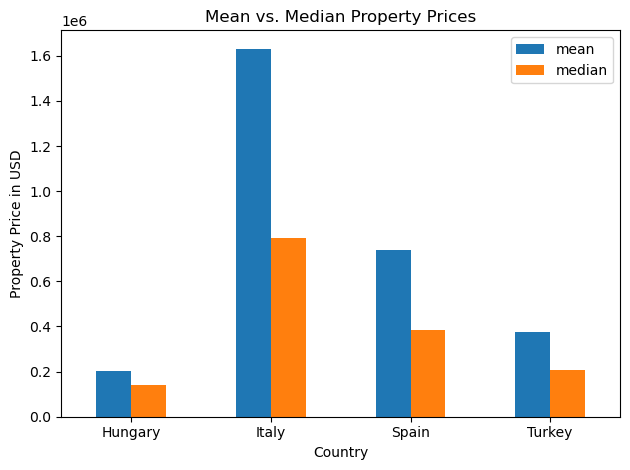

In [31]:
# Price Comparison Mean vs. Median for Spain, Turkey, Hungary and Italy

countries = ['Spain', 'Turkey', 'Hungary', 'Italy']

price_comparison = (
    df[df['country'].isin(countries)]
    .groupby('country')['price_in_USD']
    .agg(['mean', 'median'])
)

price_comparison.plot(kind='bar')

plt.title('Mean vs. Median Property Prices')
plt.xlabel('Country')
plt.ylabel('Property Price in USD')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Mean vs. Median Price Comparison

The comparison shows that the mean property price is higher than the median in all four countries.

- **Italy** has the highest mean and median prices, with a particularly large difference between the two values.
- **Spain** also shows a noticeable difference between mean and median.
- **Turkey** and **Hungary** have considerably lower price levels, but their means are still higher than their medians.
- The higher mean values are consistent with the right-skewed distributions observed in the boxplots, indicating that high-priced properties are pulling the average price upward.

Overall, the median appears to provide a more representative measure of the typical property price than the mean when extreme values are present.